# 7.3 — Phân tích Pilot (Improved)



In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score, confusion_matrix, accuracy_score, precision_score, recall_score
from statsmodels.stats.contingency_tables import mcnemar

pd.set_option('display.max_colwidth', 80)


## 1. Load dữ liệu thô 

Nguồn: results/pilot_llm_output_improved.csv và data/pilot_ground_truth_improved.csv
.


In [2]:

llm_full = pd.read_csv('../results/pilot_llm_output_improved.csv', encoding='utf-8-sig')
gt_full  = pd.read_csv('../data/pilot_ground_truth_improved.csv', encoding='utf-8-sig')

llm = llm_full[['issue_key', 's2r_label', 'reason']].copy()
gt = gt_full[['BUG-ID', 'S2R Label', 'Reason']].copy()

print(f"LLM output (Improved): {len(llm)} dòng, cột dùng = {list(llm.columns)}")
print(f"Ground truth (Improved): {len(gt)} dòng, cột dùng = {list(gt.columns)}")


LLM output (Improved): 26 dòng, cột dùng = ['issue_key', 's2r_label', 'reason']
Ground truth (Improved): 26 dòng, cột dùng = ['BUG-ID', 'S2R Label', 'Reason']


In [3]:

# In toàn bộ nhãn LLM để đối chiếu trực tiếp với file CSV gốc
llm[['issue_key', 's2r_label']]


,issue_key,s2r_label
0,MC-300962,Executable
1,MC-299218,Executable
2,MC-301018,Executable
3,MC-300634,Executable
4,MC-299909,Executable
5,MC-300861,Executable
6,MC-300776,Executable
7,MC-300107,Executable
8,MC-300598,Executable
9,MC-300539,Executable


In [4]:

# In toàn bộ nhãn ground truth để đối chiếu trực tiếp với file CSV gốc
gt[['BUG-ID', 'S2R Label']]


,BUG-ID,S2R Label
0,MC-300962 Improved,Executable
1,MC-299218 Improved,Non-Executable
2,MC-301018 Improved,Executable
3,MC-300634 Improved,Non-Executable
4,MC-299909 Improved,Executable
5,MC-300861 Improved,Executable
6,MC-300776 Improved,Executable
7,MC-300107 Improved,Executable
8,MC-300598 Improved,Non-Executable
9,MC-300539 Improved,Executable


## 2. Merge dữ liệu


In [5]:

gt['issue_key'] = gt['BUG-ID'].str.replace(' Improved', '', regex=False).str.strip()

merged = llm.merge(gt, on='issue_key', how='outer', indicator=True)
mismatch = merged[merged['_merge'] != 'both']
print(f"Số dòng KHÔNG khớp được giữa 2 file: {len(mismatch)}")
mismatch[['issue_key', '_merge']]


Số dòng KHÔNG khớp được giữa 2 file: 0


,issue_key,_merge


In [6]:

assert len(mismatch) == 0, "Có issue_key không khớp — dừng lại, báo LR/DG."
merged = merged.drop(columns=['_merge'])
merged = merged.rename(columns={'s2r_label': 'llm_label', 'S2R Label': 'human_label',
                                 'reason': 'llm_reason', 'Reason': 'human_reason'})
merged[['issue_key', 'llm_label', 'human_label']]


,issue_key,llm_label,human_label
0,MC-299218,Executable,Non-Executable
1,MC-299909,Executable,Executable
2,MC-300031,Executable,Executable
3,MC-300033,Executable,Executable
4,MC-300107,Executable,Executable
5,MC-300409,Executable,Non-Executable
6,MC-300420,Executable,Executable
7,MC-300539,Executable,Executable
8,MC-300562,Executable,Executable
9,MC-300598,Executable,Non-Executable


## 3. Confusion matrix 

Đếm thủ công 4 ô, sau đó đối chiếu với `sklearn.metrics.confusion_matrix`.


In [7]:

y_true = merged['human_label']
y_pred = merged['llm_label']
n = len(merged)

tp = ((y_true=='Non-Executable') & (y_pred=='Non-Executable')).sum()
fn = ((y_true=='Non-Executable') & (y_pred=='Executable')).sum()
fp = ((y_true=='Executable') & (y_pred=='Non-Executable')).sum()
tn = ((y_true=='Executable') & (y_pred=='Executable')).sum()

print("Đếm tay:")
print(f"  Human=Non-Executable, LLM=Non-Executable : {tp}")
print(f"  Human=Non-Executable, LLM=Executable     : {fn}")
print(f"  Human=Executable,     LLM=Non-Executable : {fp}")
print(f"  Human=Executable,     LLM=Executable     : {tn}")
print(f"  Tổng: {tp+fn+fp+tn} (phải = N = {n})")

labels = ['Executable', 'Non-Executable']
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"human: {l}" for l in labels], columns=[f"llm: {l}" for l in labels])
print("\nĐối chiếu với sklearn.metrics.confusion_matrix:")
cm_df


Đếm tay:
  Human=Non-Executable, LLM=Non-Executable : 0
  Human=Non-Executable, LLM=Executable     : 7
  Human=Executable,     LLM=Non-Executable : 0
  Human=Executable,     LLM=Executable     : 19
  Tổng: 26 (phải = N = 26)

Đối chiếu với sklearn.metrics.confusion_matrix:


,llm: Executable,llm: Non-Executable
human: Executable,19,0
human: Non-Executable,7,0


## 4. Tính metric trên pilot output — Cohen's Kappa

Công thức: κ = (p_o − p_e) / (1 − p_e)


In [8]:

po = (tp + tn) / n
p_human_nonexec = (y_true == 'Non-Executable').mean()
p_llm_nonexec = (y_pred == 'Non-Executable').mean()
pe = p_human_nonexec * p_llm_nonexec + (1 - p_human_nonexec) * (1 - p_llm_nonexec)
kappa_manual = (po - pe) / (1 - pe) if pe != 1 else float('nan')

kappa_sklearn = cohen_kappa_score(y_true, y_pred, labels=labels)

print(f"Observed agreement (po) = {po:.4f}")
print(f"Expected agreement (pe) = {pe:.4f}")
print(f"Cohen's Kappa (tính tay) = {kappa_manual:.4f}")
print(f"Cohen's Kappa (sklearn)  = {kappa_sklearn:.4f}")
assert abs(kappa_manual - kappa_sklearn) < 1e-9, "Hai cách tính KHÔNG khớp — dừng lại kiểm tra."
print("\n=> Hai cách tính khớp nhau tuyệt đối.")


Observed agreement (po) = 0.7308
Expected agreement (pe) = 0.7308
Cohen's Kappa (tính tay) = -0.0000
Cohen's Kappa (sklearn)  = 0.0000

=> Hai cách tính khớp nhau tuyệt đối.


In [9]:

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, pos_label='Non-Executable', zero_division=0)
rec = recall_score(y_true, y_pred, pos_label='Non-Executable', zero_division=0)
print(f"Accuracy                   : {acc:.4f}")
print(f"Precision (Non-Executable) : {prec:.4f}")
print(f"Recall (Non-Executable)    : {rec:.4f}")


Accuracy                   : 0.7308
Precision (Non-Executable) : 0.0000
Recall (Non-Executable)    : 0.0000


In [10]:

# Bootstrap 95% CI cho Kappa (proposal §6.1), seed cố định để tái lập
rng = np.random.default_rng(42)
n_boot = 2000
boot_kappas = []

for _ in range(n_boot):
    idx = rng.integers(0, n, n)
    yt = y_true.values[idx]
    yp = y_pred.values[idx]
    if len(set(yt)) < 2 and len(set(yp)) < 2:
        continue
    boot_kappas.append(cohen_kappa_score(yt, yp, labels=labels))

ci_low, ci_high = np.percentile(boot_kappas, [2.5, 97.5])
print(f"Bootstrap 95% CI cho Kappa: [{ci_low:.4f}, {ci_high:.4f}]  (n_boot={len(boot_kappas)}, seed=42)")


Bootstrap 95% CI cho Kappa: [0.0000, 0.0000]  (n_boot=1999, seed=42)


## 5. Vẽ histogram phân phối (Improved)

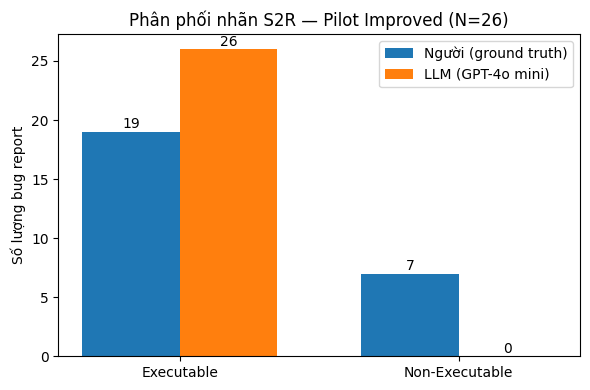

Người:  Executable=19, Non-Executable=7
LLM:    Executable=26, Non-Executable=0


In [11]:

fig, ax = plt.subplots(figsize=(6, 4))
counts_human = y_true.value_counts().reindex(labels, fill_value=0)
counts_llm = y_pred.value_counts().reindex(labels, fill_value=0)

x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, counts_human.values, width, label='Người (ground truth)')
ax.bar(x + width/2, counts_llm.values, width, label='LLM (GPT-4o mini)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Số lượng bug report')
ax.set_title(f'Phân phối nhãn S2R — Pilot Improved (N={n})')
ax.legend()
for i, v in enumerate(counts_human.values):
    ax.text(i - width/2, v + 0.3, str(v), ha='center')
for i, v in enumerate(counts_llm.values):
    ax.text(i + width/2, v + 0.3, str(v), ha='center')
plt.tight_layout()
plt.show()

print(f"Người:  Executable={counts_human['Executable']}, Non-Executable={counts_human['Non-Executable']}")
print(f"LLM:    Executable={counts_llm['Executable']}, Non-Executable={counts_llm['Non-Executable']}")


## 6. Xác nhận lại lựa chọn statistical test (Improved)

Proposal §5.1 dự kiến Wilcoxon signed-rank test — giả định điểm dạng số liên tục/ordinal (1–5).
Dữ liệu thực tế (Improved): nhãn categorical nhị phân (Executable/Non-Executable) → **khác dự kiến trong proposal**.

Theo bảng quyết định §7.4: *"Phân phối data rất khác dự kiến → Ghi vào notes.md, GV quyết định có amendment không."*
Test phù hợp hơn cho dữ liệu categorical nhị phân theo cặp: **McNemar's test**.


In [12]:

result = mcnemar(cm, exact=True)
print(f"McNemar's test: statistic = {result.statistic}, p-value = {result.pvalue:.4f}")
print("\nPhân phối như dự kiến trong proposal (numeric 1-5)? False — dữ liệu là categorical nhị phân.")
print("=> Đề xuất: dùng McNemar's test thay Wilcoxon cho Tuần 8. Cần ghi notes.md + báo GV/PL.")


McNemar's test: statistic = 0.0, p-value = 0.0156

Phân phối như dự kiến trong proposal (numeric 1-5)? False — dữ liệu là categorical nhị phân.
=> Đề xuất: dùng McNemar's test thay Wilcoxon cho Tuần 8. Cần ghi notes.md + báo GV/PL.


## 7. Kết luận pilot & gate theo proposal §5.1 (Improved)

In [13]:

print(f"N pilot (Improved)       : {n}")
print(f"Cohen's Kappa (κ_LLM pilot): {kappa_manual:.4f}  (95% CI [{ci_low:.4f}, {ci_high:.4f}])")
print(f"Ngưỡng gate proposal §5.1  : κ_LLM pilot >= 0.40")
print(f"Gate pilot                 : {'ĐẠT' if kappa_manual >= 0.40 else 'KHÔNG ĐẠT'}")


N pilot (Improved)       : 26
Cohen's Kappa (κ_LLM pilot): -0.0000  (95% CI [0.0000, 0.0000])
Ngưỡng gate proposal §5.1  : κ_LLM pilot >= 0.40
Gate pilot                 : KHÔNG ĐẠT
